**Decision Tree Classifier: Bank Marketing Dataset**


**STEP 1: Install & Import Libraries**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import urllib.request
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

print("Libraries imported successfully")

Libraries imported successfully


 **STEP 2: Load Dataset**

In [14]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
urllib.request.urlretrieve(url, "bank.zip")

with zipfile.ZipFile("bank.zip", "r") as z:
    z.extractall(".")

df = pd.read_csv("bank-additional/bank-additional-full.csv", sep=";")

print(f"Shape: {df.shape}")
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


**STEP 3: Basic EDA**

In [15]:
print("── Data Info ──")
df.info()
print("\n── Null Values ──")
print(df.isnull().sum())
print("\n── Target Distribution ──")
print(df['y'].value_counts())
df.describe()

── Data Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx  

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**STEP 4: EDA Visualisations**

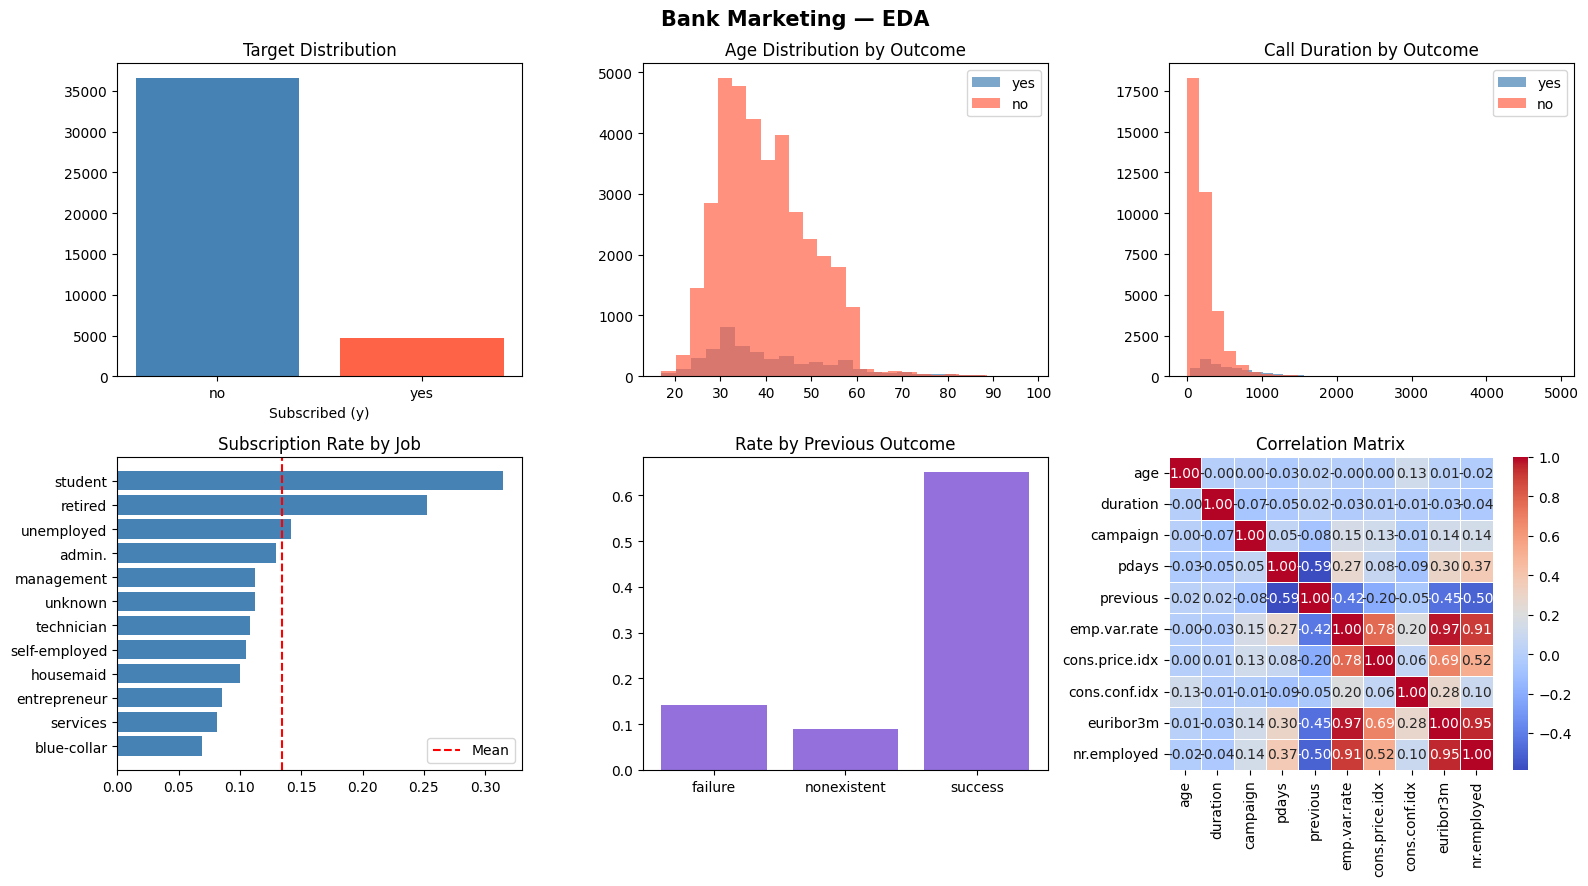

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Bank Marketing — EDA", fontsize=15, fontweight="bold")

# Target distribution
counts = df['y'].value_counts()
axes[0,0].bar(counts.index, counts.values, color=['steelblue','tomato'])
axes[0,0].set_title("Target Distribution")
axes[0,0].set_xlabel("Subscribed (y)")

# Age distribution
for label, color in zip(['yes','no'], ['steelblue','tomato']):
    axes[0,1].hist(df[df['y']==label]['age'], bins=25, alpha=0.7,
                   color=color, label=label)
axes[0,1].set_title("Age Distribution by Outcome")
axes[0,1].legend()

# Call duration
for label, color in zip(['yes','no'], ['steelblue','tomato']):
    axes[0,2].hist(df[df['y']==label]['duration'], bins=30, alpha=0.7,
                   color=color, label=label)
axes[0,2].set_title("Call Duration by Outcome")
axes[0,2].legend()

# Job vs subscription rate
job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()).sort_values()
axes[1,0].barh(job_rate.index, job_rate.values, color='steelblue')
axes[1,0].axvline(job_rate.mean(), color='red', linestyle='--', label='Mean')
axes[1,0].set_title("Subscription Rate by Job")
axes[1,0].legend()

# Previous outcome vs rate
po_rate = df.groupby('poutcome')['y'].apply(lambda x: (x=='yes').mean())
axes[1,1].bar(po_rate.index, po_rate.values, color='mediumpurple')
axes[1,1].set_title("Rate by Previous Outcome")

# Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), ax=axes[1,2], cmap='coolwarm',
            annot=True, fmt='.2f', linewidths=0.5)
axes[1,2].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

**STEP 5: Preprocessing**

In [17]:
le = LabelEncoder()
df_enc = df.copy()

cat_cols = df_enc.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')

for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

df_enc['y'] = (df_enc['y'] == 'yes').astype(int)

X = df_enc.drop('y', axis=1)
y = df_enc['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 32950 | Test: 8238


**STEP 6: Baseline Model**

In [18]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")

Baseline Accuracy: 0.8956


**STEP 7: Hyperparameter Tuning with GridSearchCV**

In [23]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Best Params      : {grid_search.best_params_}")

Best CV Accuracy : 0.9127
Best Params      : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


**STEP 8: Evaluate Best Model**

In [24]:
dt_best = grid_search.best_estimator_
y_pred  = dt_best.predict(X_test)
y_prob  = dt_best.predict_proba(X_test)[:, 1]

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No','Yes']))

Test Accuracy : 0.9181
ROC-AUC       : 0.9335

Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.97      0.95      7310
         Yes       0.68      0.52      0.59       928

    accuracy                           0.92      8238
   macro avg       0.81      0.74      0.77      8238
weighted avg       0.91      0.92      0.91      8238



**STEP 9: Confusion Matrix + ROC Curve**

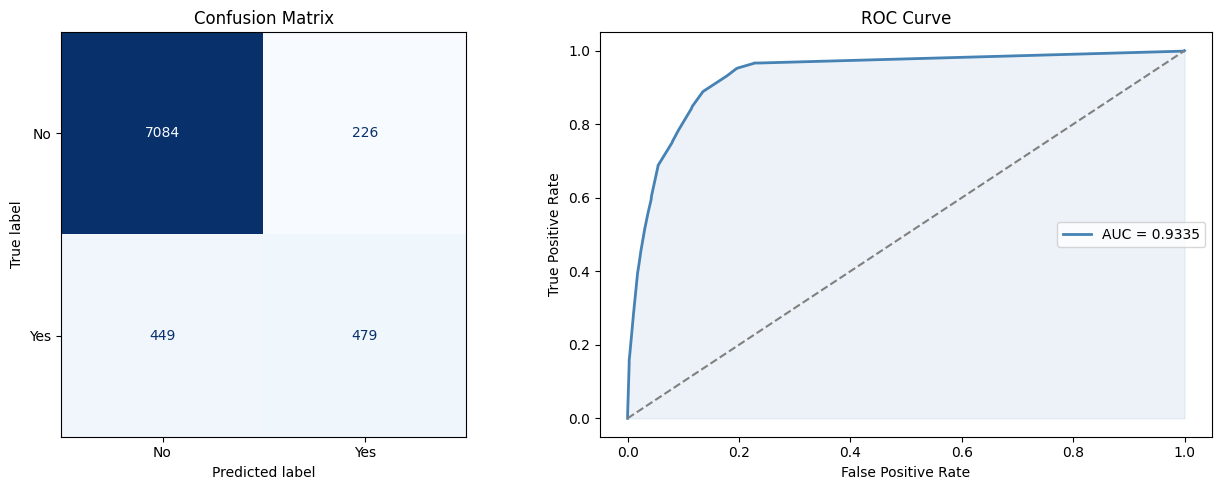

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['No','Yes']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

**STEP 10: Feature Importance**

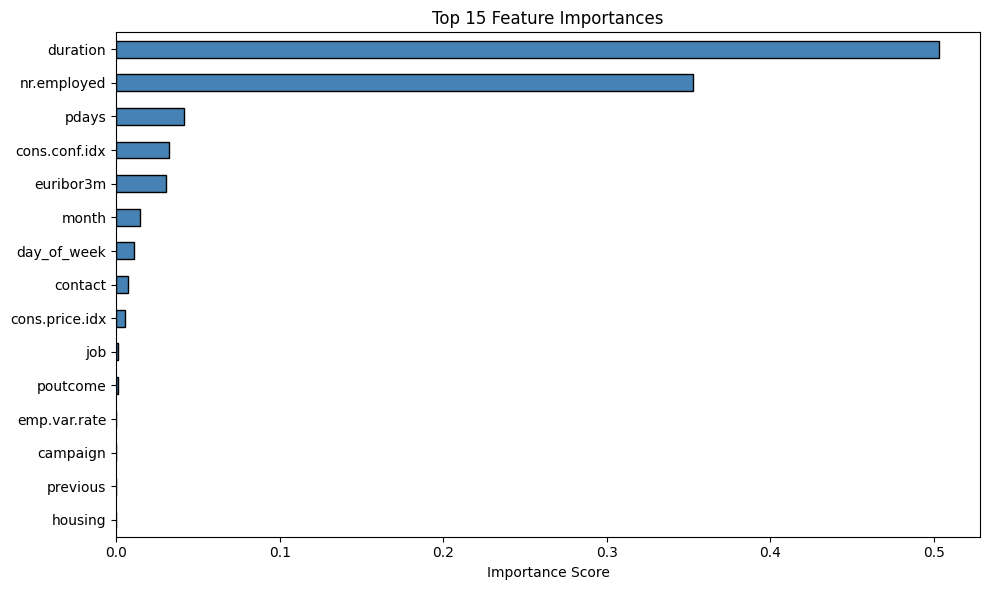

In [26]:
importances = pd.Series(dt_best.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

**STEP 11: Visualise Decision Tree (depth=3)**

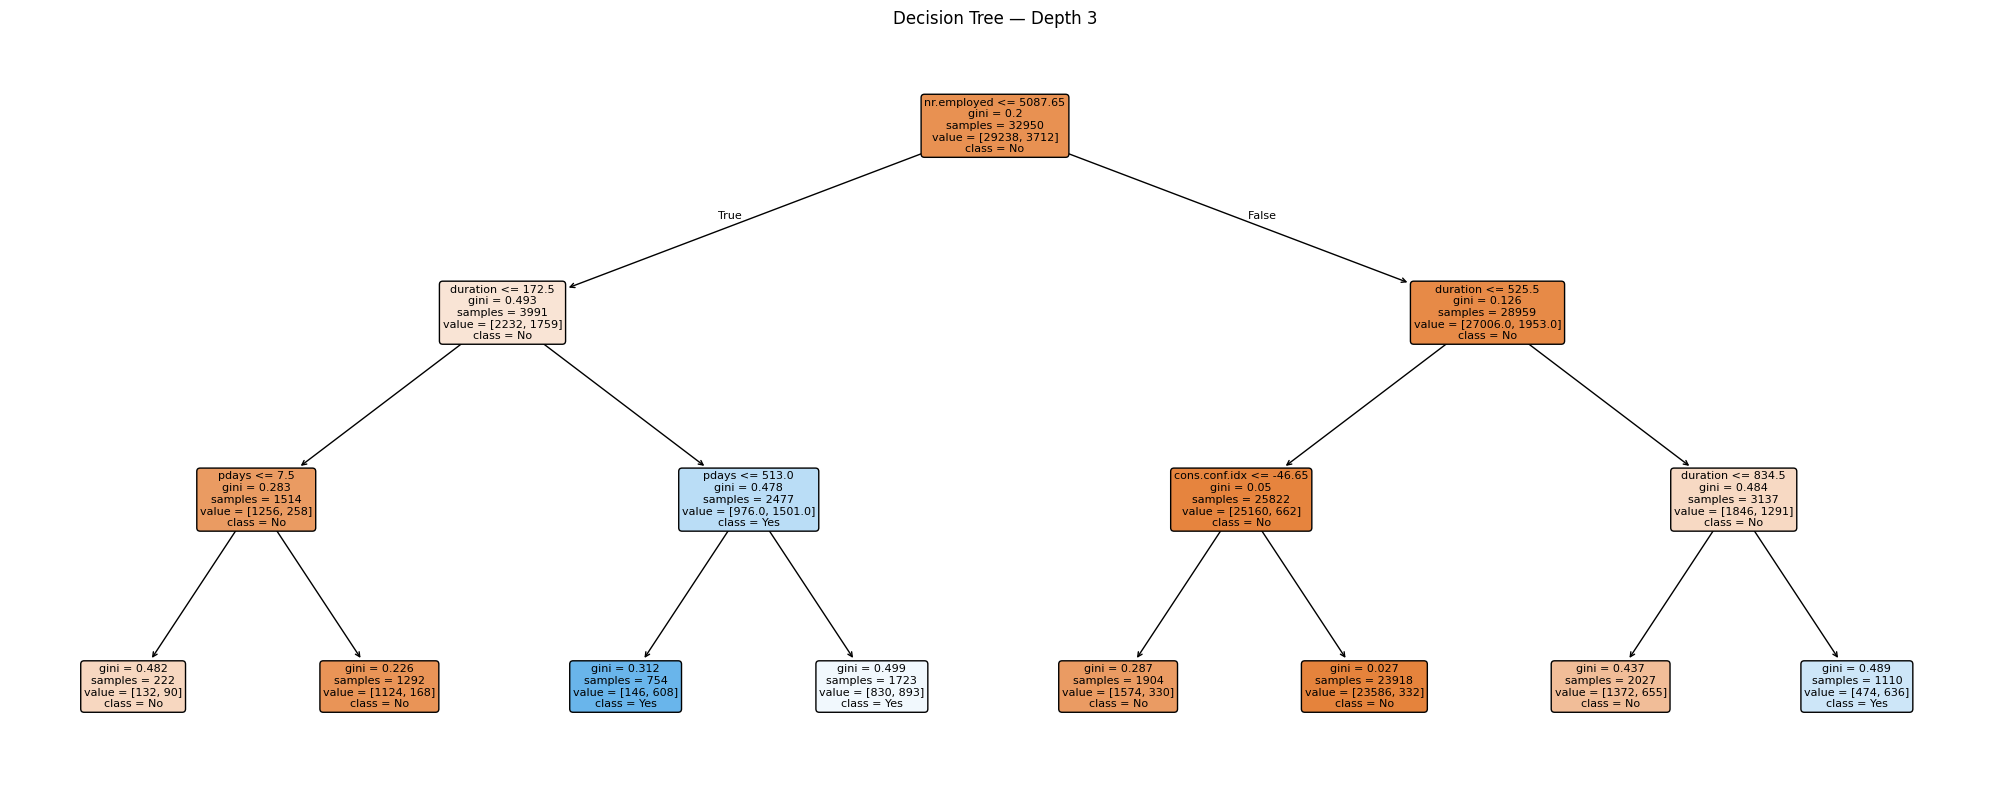

In [27]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train),
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True, rounded=True, fontsize=8, ax=ax
)
plt.title("Decision Tree — Depth 3")
plt.tight_layout()
plt.show()

**STEP 12: Cross-Validation**

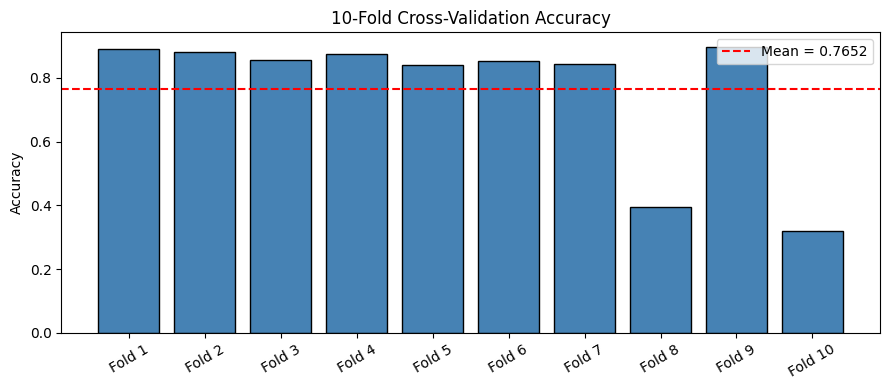


10-CV Mean ± STD: 0.7652 ± 0.2053


In [28]:
cv_scores = cross_val_score(dt_best, X, y, cv=10, scoring='accuracy')

plt.figure(figsize=(9, 4))
plt.bar([f"Fold {i+1}" for i in range(10)], cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f"Mean = {cv_scores.mean():.4f}")
plt.title("10-Fold Cross-Validation Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n10-CV Mean ± STD: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

In [31]:
# STEP 13: Final Summary
print("=" * 50)
print("       DECISION TREE CLASSIFIER - SUMMARY")
print("=" * 50)
print(f"  Dataset        : Bank Marketing (UCI)")
print(f"  Total Records  : {df.shape[0]}")
print(f"  Total Features : {df.shape[1] - 1}")
print(f"  Algorithm      : Decision Tree Classifier")
print(f"  Best Criterion : {grid_search.best_params_['criterion']}")
print(f"  Best Depth     : {grid_search.best_params_['max_depth']}")
print(f"  Train Size     : {X_train.shape[0]}")
print(f"  Test Size      : {X_test.shape[0]}")
print("-" * 50)
print(f"  Baseline Acc   : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  Tuned Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC Score  : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  CV Mean ± STD  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 50)
print("Project Complete!")
print("=" * 50)

       DECISION TREE CLASSIFIER - SUMMARY
  Dataset        : Bank Marketing (UCI)
  Total Records  : 41188
  Total Features : 20
  Algorithm      : Decision Tree Classifier
  Best Criterion : gini
  Best Depth     : 5
  Train Size     : 32950
  Test Size      : 8238
--------------------------------------------------
  Baseline Acc   : 0.8956
  Tuned Accuracy : 0.9181
  ROC-AUC Score  : 0.9335
  CV Mean ± STD  : 0.7652 ± 0.2053
Project Complete!
